# Inverse mixed PINN for 2D linear elastostatics

The goal is to approximate two displacement components and three stress components on

$$
\Omega=(0,1)^2,
$$

while the Lamé parameters $\lambda$ and $\mu$ are unknown trainable parameters. Five separate neural networks approximate

$$
u_{x,\theta},\qquad u_{y,\theta},\qquad \sigma_{xx,\theta},\qquad \sigma_{yy,\theta},\qquad \sigma_{xy,\theta}.
$$

Their outputs are collected as

$$
\mathbf q_\theta(x,y)=
\begin{bmatrix}
u_{x,\theta} & u_{y,\theta} & \sigma_{xx,\theta} & \sigma_{yy,\theta} & \sigma_{xy,\theta}
\end{bmatrix}^{\mathsf T}.
$$

For the synthetic inverse experiment, the hidden true values are $\lambda_{\mathrm{true}}=1$ and $\mu_{\mathrm{true}}=1/2$. The exact displacement is

$$
u_{x,\mathrm{exact}}(x,y)=\cos(2\pi x)\sin(\pi y),
\qquad
u_{y,\mathrm{exact}}(x,y)=\frac{Q}{4}\sin(\pi x)y^4,
\qquad Q=4.
$$

## Strong formulation

The infinitesimal-strain tensor, plane-strain constitutive law, and equilibrium equation are

$$
\boldsymbol\varepsilon(\mathbf u)=\frac12\left(\nabla\mathbf u+\nabla\mathbf u^{\mathsf T}\right),
\qquad
\boldsymbol\sigma=\lambda\operatorname{tr}(\boldsymbol\varepsilon)\mathbf I+2\mu\boldsymbol\varepsilon,
\qquad
\nabla\cdot\boldsymbol\sigma+\mathbf f=\mathbf0.
$$

Force-complete data provide the exact displacement, stress, and body force on the training grid. The body force is used in the equilibrium residual. Boundary conditions are not included as a separate loss because full-field observations are available throughout the domain, including its boundary.

## 1. Library imports

In [17]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float64)

## 2. Configuration

- `USE_NOISY_DATA = False` uses exact observations.
- `USE_NOISY_DATA = True` adds independent zero-mean Gaussian noise with a component-wise standard deviation equal to `NOISE_RELATIVE_STD` times the maximum absolute value of the corresponding field.
- A single $100\times100$ uniform Cartesian grid is used for training.
- The supervised data points and the physics collocation points have identical coordinates.
- No validation or test split is introduced.
- Four independent-network architectures are trained separately and compared.
- Adam updates $\lambda$, $\mu$, and all neural-network parameters simultaneously.
- Early stopping monitors the total training loss with a patience of 500 epochs.

In [18]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02

LAMBDA_TRUE = 1.0
MU_TRUE = 0.5
Q = 4.0
INITIAL_LAMBDA = 2.0
INITIAL_MU = 2.0

N_SIDE_TRAIN = 100
N_PDE_TRAIN = N_SIDE_TRAIN**2
N_DATA_TRAIN = N_PDE_TRAIN
PDE_BATCH_SIZE = 64
EVALUATION_SIDE = 200

EPOCHS = 10_000
LR = 1e-3
PATIENCE = 500
SEED = 42
PRINT_EVERY = 500

PLOT_ARCHITECTURE = "iv"

torch.manual_seed(SEED)
print(f"True lambda = {LAMBDA_TRUE:.6f}, true mu = {MU_TRUE:.6f}")
print(f"Initial lambda = {INITIAL_LAMBDA:.6f}, initial mu = {INITIAL_MU:.6f}")
print(f"Data mode: {'noisy' if USE_NOISY_DATA else 'exact'}")

True lambda = 1.000000, true mu = 0.500000
Initial lambda = 2.000000, initial mu = 2.000000
Data mode: noisy


## 3. Exact displacement, stress, and body force

In [19]:
def exact_displacement(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    ux = torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
    uy = 0.25 * Q * torch.sin(torch.pi * x) * y**4
    return torch.cat((ux, uy), dim=1)

def exact_strain(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    eps_xx = -2.0 * torch.pi * torch.sin(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
    eps_yy = Q * torch.sin(torch.pi * x) * y**3
    eps_xy = 0.5 * (torch.pi * torch.cos(2.0 * torch.pi * x) * torch.cos(torch.pi * y)
                    + 0.25 * Q * torch.pi * torch.cos(torch.pi * x) * y**4)
    return torch.cat((eps_xx, eps_yy, eps_xy), dim=1)

def exact_stress(xy):
    eps_xx, eps_yy, eps_xy = exact_strain(xy).split(1, dim=1)
    sigma_xx = (LAMBDA_TRUE + 2.0 * MU_TRUE) * eps_xx + LAMBDA_TRUE * eps_yy
    sigma_yy = (LAMBDA_TRUE + 2.0 * MU_TRUE) * eps_yy + LAMBDA_TRUE * eps_xx
    sigma_xy = 2.0 * MU_TRUE * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)

def exact_fields(xy):
    return torch.cat((exact_displacement(xy), exact_stress(xy)), dim=1)

def body_force(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    fx = LAMBDA_TRUE * (4.0 * torch.pi**2 * torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
                        - torch.pi * torch.cos(torch.pi * x) * Q * y**3)
    fx += MU_TRUE * (9.0 * torch.pi**2 * torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
                     - torch.pi * torch.cos(torch.pi * x) * Q * y**3)
    fy = LAMBDA_TRUE * (-3.0 * torch.sin(torch.pi * x) * Q * y**2
                        + 2.0 * torch.pi**2 * torch.sin(2.0 * torch.pi * x) * torch.cos(torch.pi * y))
    fy += MU_TRUE * (-6.0 * torch.sin(torch.pi * x) * Q * y**2
                     + 2.0 * torch.pi**2 * torch.sin(2.0 * torch.pi * x) * torch.cos(torch.pi * y)
                     + 0.25 * torch.pi**2 * torch.sin(torch.pi * x) * Q * y**4)
    return torch.cat((fx, fy), dim=1)

## 4. Five independent neural networks and trainable material parameters

One independent scalar-output network is used for each field:

$$
\mathcal N_{u_x},\qquad \mathcal N_{u_y},\qquad
\mathcal N_{\sigma_{xx}},\qquad \mathcal N_{\sigma_{yy}},\qquad
\mathcal N_{\sigma_{xy}}.
$$

The networks do not share weights or biases. Every architecture below is written explicitly using `nn.Sequential`; no loop constructs the hidden layers. Each scalar field uses its own copy of the corresponding architecture. All hidden layers use $\tanh$, and $\lambda_\theta$ and $\mu_\theta$ are shared trainable parameters.

In [20]:
def initialize_xavier(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_normal_(module.weight)
        nn.init.uniform_(module.bias, -0.05, 0.05)

def number_of_network_parameters(model):
    return sum(
        parameter.numel()
        for name, parameter in model.named_parameters()
        if name not in {"lame_lambda", "lame_mu"}
    )

### Net i: 5 hidden layers, 20 neurons per layer

In [ ]:
class FieldNetworkI(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetI(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkI()
        self.uy_network = FieldNetworkI()
        self.sigma_xx_network = FieldNetworkI()
        self.sigma_yy_network = FieldNetworkI()
        self.sigma_xy_network = FieldNetworkI()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_i_preview = PINNNetI()
print(f"Net i parameters: {number_of_network_parameters(model_i_preview):,}")

### Net ii: 5 hidden layers, 50 neurons per layer

In [6]:
class FieldNetworkII(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetII(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkII()
        self.uy_network = FieldNetworkII()
        self.sigma_xx_network = FieldNetworkII()
        self.sigma_yy_network = FieldNetworkII()
        self.sigma_xy_network = FieldNetworkII()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_ii_preview = PINNNetII()
print(f"Net ii parameters: {number_of_network_parameters(model_ii_preview):,}")

Net ii parameters: 52,005


### Net iii: 10 hidden layers, 20 neurons per layer

In [7]:
class FieldNetworkIII(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetIII(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkIII()
        self.uy_network = FieldNetworkIII()
        self.sigma_xx_network = FieldNetworkIII()
        self.sigma_yy_network = FieldNetworkIII()
        self.sigma_xy_network = FieldNetworkIII()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_iii_preview = PINNNetIII()
print(f"Net iii parameters: {number_of_network_parameters(model_iii_preview):,}")

Net iii parameters: 19,305


### Net iv: 10 hidden layers, 50 neurons per layer

In [8]:
class FieldNetworkIV(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetIV(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkIV()
        self.uy_network = FieldNetworkIV()
        self.sigma_xx_network = FieldNetworkIV()
        self.sigma_yy_network = FieldNetworkIV()
        self.sigma_xy_network = FieldNetworkIV()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_iv_preview = PINNNetIV()
print(f"Net iv parameters: {number_of_network_parameters(model_iv_preview):,}")

Net iv parameters: 115,755


## 5. Shared data and collocation points

The training coordinates form one uniform Cartesian grid including the boundary. At every coordinate, the five supervised field values and all equilibrium and constitutive residuals are evaluated. Thus, the data points and collocation points coincide exactly. The observations are either exact or Gaussian-noisy according to `USE_NOISY_DATA`.

In [22]:
def uniform_grid(n_side):
    values = torch.linspace(0.0, 1.0, n_side)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)

def observed_fields(xy, seed):
    exact = exact_fields(xy)
    if not USE_NOISY_DATA:
        return exact
    scales = torch.amax(torch.abs(exact), dim=0, keepdim=True).clamp_min(torch.finfo(exact.dtype).eps)
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * scales * noise

xy_train = uniform_grid(N_SIDE_TRAIN)
xy_pde_train = xy_train
xy_data_train = xy_train
fields_data_train = observed_fields(xy_data_train, SEED + 20)

print(f"Shared training grid: {N_SIDE_TRAIN} x {N_SIDE_TRAIN}")
print(f"PDE points: {len(xy_pde_train)}")
print(f"Data points: {len(xy_data_train)}")
print(f"Coordinates coincide: {torch.equal(xy_pde_train, xy_data_train)}")

Shared training grid: 100 x 100
PDE points: 10000
Data points: 10000
Coordinates coincide: True


## 6. Equilibrium and constitutive residuals

Because the stress components are approximated independently, the physics loss contains equilibrium and constitutive residuals:

$$
\mathbf r_{\mathrm{eq},\theta}=\nabla\cdot\boldsymbol\sigma_\theta+\mathbf f,
\qquad
\mathbf r_{\mathrm{const},\theta}=\boldsymbol\sigma_\theta-
\left[\lambda_\theta\operatorname{tr}(\boldsymbol\varepsilon(\mathbf u_\theta))\mathbf I
+2\mu_\theta\boldsymbol\varepsilon(\mathbf u_\theta)\right].
$$

The complete loss is the equally weighted sum of ten MSE terms:

$$
\mathcal L=\mathcal L_u+\mathcal L_\sigma+\mathcal L_{\mathrm{eq}}+\mathcal L_{\mathrm{const}}.
$$

There are two displacement-data terms, three stress-data terms, two equilibrium terms, and three constitutive terms. No separate boundary-condition loss is added.

In [23]:
def split_prediction(prediction):
    return prediction[:, 0:1], prediction[:, 1:2], prediction[:, 2:3], prediction[:, 3:4], prediction[:, 4:5]

def constitutive_stress_from_displacement(model, xy, ux, uy, create_graph):
    grad_ux = torch.autograd.grad(ux, xy, torch.ones_like(ux), create_graph=create_graph, retain_graph=True)[0]
    grad_uy = torch.autograd.grad(uy, xy, torch.ones_like(uy), create_graph=create_graph, retain_graph=True)[0]
    eps_xx = grad_ux[:, 0:1]
    eps_yy = grad_uy[:, 1:2]
    eps_xy = 0.5 * (grad_ux[:, 1:2] + grad_uy[:, 0:1])
    sigma_xx = (model.lame_lambda + 2.0 * model.lame_mu) * eps_xx + model.lame_lambda * eps_yy
    sigma_yy = (model.lame_lambda + 2.0 * model.lame_mu) * eps_yy + model.lame_lambda * eps_xx
    sigma_xy = 2.0 * model.lame_mu * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)

def mixed_residuals(model, xy, training=True):
    xy = xy.detach().clone().requires_grad_(True)
    prediction = model(xy)
    ux, uy, sigma_xx, sigma_yy, sigma_xy = split_prediction(prediction)
    predicted_stress = torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)
    constitutive_stress = constitutive_stress_from_displacement(model, xy, ux, uy, create_graph=training)
    residual_constitutive = predicted_stress - constitutive_stress
    grad_sigma_xx = torch.autograd.grad(sigma_xx, xy, torch.ones_like(sigma_xx), create_graph=training, retain_graph=True)[0]
    grad_sigma_yy = torch.autograd.grad(sigma_yy, xy, torch.ones_like(sigma_yy), create_graph=training, retain_graph=True)[0]
    grad_sigma_xy = torch.autograd.grad(sigma_xy, xy, torch.ones_like(sigma_xy), create_graph=training, retain_graph=True)[0]
    force = body_force(xy)
    residual_x = grad_sigma_xx[:, 0:1] + grad_sigma_xy[:, 1:2] + force[:, 0:1]
    residual_y = grad_sigma_xy[:, 0:1] + grad_sigma_yy[:, 1:2] + force[:, 1:2]
    return torch.cat((residual_x, residual_y), dim=1), residual_constitutive, prediction

def compute_losses(model, xy, observed, training=True):
    residual_eq, residual_const, prediction = mixed_residuals(model, xy, training=training)
    data_error = prediction - observed

    loss_u_x = torch.mean(data_error[:, 0]**2)
    loss_u_y = torch.mean(data_error[:, 1]**2)
    loss_sigma_xx = torch.mean(data_error[:, 2]**2)
    loss_sigma_yy = torch.mean(data_error[:, 3]**2)
    loss_sigma_xy = torch.mean(data_error[:, 4]**2)

    loss_equilibrium_x = torch.mean(residual_eq[:, 0]**2)
    loss_equilibrium_y = torch.mean(residual_eq[:, 1]**2)
    loss_constitutive_xx = torch.mean(residual_const[:, 0]**2)
    loss_constitutive_yy = torch.mean(residual_const[:, 1]**2)
    loss_constitutive_xy = torch.mean(residual_const[:, 2]**2)

    loss_displacement = loss_u_x + loss_u_y
    loss_stress = loss_sigma_xx + loss_sigma_yy + loss_sigma_xy
    loss_equilibrium = loss_equilibrium_x + loss_equilibrium_y
    loss_constitutive = loss_constitutive_xx + loss_constitutive_yy + loss_constitutive_xy
    loss_data = loss_displacement + loss_stress
    loss = loss_data + loss_equilibrium + loss_constitutive

    return (
        loss,
        loss_equilibrium,
        loss_constitutive,
        loss_data,
        loss_displacement,
        loss_stress,
        loss_u_x,
        loss_u_y,
        loss_sigma_xx,
        loss_sigma_yy,
        loss_sigma_xy,
        loss_equilibrium_x,
        loss_equilibrium_y,
        loss_constitutive_xx,
        loss_constitutive_yy,
        loss_constitutive_xy,
    )


## 7. Training and early stopping

Each architecture is trained independently. The data are reshuffled after every epoch. Since no validation set is used, early stopping and checkpoint selection are based on the total training loss. Training stops after 500 consecutive epochs without improvement or after 10,000 epochs.

In [24]:
def clone_model_state(model):
    return {name: value.detach().clone() for name, value in model.state_dict().items()}

def train_architecture(name, model_class, seed):
    torch.manual_seed(seed)
    model = model_class()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    generator = torch.Generator().manual_seed(seed + 1)
    loader = DataLoader(
        TensorDataset(xy_pde_train, fields_data_train),
        batch_size=PDE_BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )
    keys = [
        "total", "equilibrium", "constitutive", "data", "displacement", "stress",
        "u_x", "u_y", "sigma_xx", "sigma_yy", "sigma_xy",
        "equilibrium_x", "equilibrium_y",
        "constitutive_xx", "constitutive_yy", "constitutive_xy",
    ]
    history = {key: [] for key in keys}
    lambda_history = []
    mu_history = []
    best_training_loss = float("inf")
    best_epoch = None
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        epoch_sums = np.zeros(len(keys))
        samples = 0
        for xy_batch, fields_batch in loader:
            optimizer.zero_grad(set_to_none=True)
            losses = compute_losses(model, xy_batch, fields_batch, training=True)
            losses[0].backward()
            optimizer.step()
            epoch_sums += np.array([value.detach().item() for value in losses]) * len(xy_batch)
            samples += len(xy_batch)

        epoch_values = epoch_sums / samples
        for key, value in zip(keys, epoch_values):
            history[key].append(value)
        lambda_history.append(model.lame_lambda.detach().item())
        mu_history.append(model.lame_mu.detach().item())

        if epoch_values[0] < best_training_loss:
            best_training_loss = epoch_values[0]
            best_epoch = epoch
            best_model_state = clone_model_state(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % PRINT_EVERY == 0:
            print(
                f"Net {name} | epoch {epoch:5d} | loss={epoch_values[0]:.6e} | "
                f"lambda={lambda_history[-1]:.6f} | mu={mu_history[-1]:.6f}"
            )
        if epochs_without_improvement >= PATIENCE:
            print(f"Net {name} | early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    model.eval()
    print(
        f"Net {name} | best epoch={best_epoch} | best training loss={best_training_loss:.6e} | "
        f"lambda={model.lame_lambda.item():.8f} | mu={model.lame_mu.item():.8f}"
    )
    return {
        "model": model,
        "history": history,
        "lambda_history": lambda_history,
        "mu_history": mu_history,
        "best_training_loss": best_training_loss,
        "best_epoch": best_epoch,
        "best_model_state": best_model_state,
    }

### Training Net i

Five hidden layers with 20 neurons in each field network.

In [29]:
result_i = train_architecture(
    name="i",
    model_class=PINNNetI,
    seed=SEED,
)

Net i | epoch     0 | loss=1.868760e+03 | lambda=1.947451 | mu=1.899120
Net i | epoch   500 | loss=2.309745e-01 | lambda=0.996765 | mu=0.498594
Net i | epoch  1000 | loss=1.242845e-01 | lambda=0.997064 | mu=0.498663
Net i | epoch  1500 | loss=1.290229e-01 | lambda=0.996908 | mu=0.498890
Net i | epoch  2000 | loss=1.353707e-01 | lambda=0.997385 | mu=0.499402
Net i | epoch  2500 | loss=1.865517e-01 | lambda=0.996853 | mu=0.497860
Net i | early stopping at epoch 2568
Net i | best epoch=2068 | best training loss=1.070681e-01 | lambda=0.99614479 | mu=0.49802349


### Training Net ii

Five hidden layers with 50 neurons in each field network.

In [30]:
result_ii = train_architecture(
    name="ii",
    model_class=PINNNetII,
    seed=SEED + 100,
)

Net ii | epoch     0 | loss=1.461114e+03 | lambda=1.938409 | mu=1.873792
Net ii | epoch   500 | loss=1.248515e-01 | lambda=0.981740 | mu=0.493332
Net ii | epoch  1000 | loss=1.190511e-01 | lambda=0.987559 | mu=0.494795
Net ii | epoch  1500 | loss=2.902822e-01 | lambda=0.989237 | mu=0.496262
Net ii | early stopping at epoch 1523
Net ii | best epoch=1023 | best training loss=1.044073e-01 | lambda=0.98311829 | mu=0.49307327


### Training Net iii

Ten hidden layers with 20 neurons in each field network.

In [31]:
result_iii = train_architecture(
    name="iii",
    model_class=PINNNetIII,
    seed=SEED + 200,
)

Net iii | epoch     0 | loss=1.575187e+03 | lambda=1.887083 | mu=1.862451
Net iii | epoch   500 | loss=1.632867e-01 | lambda=0.988048 | mu=0.496747
Net iii | epoch  1000 | loss=2.345653e-01 | lambda=0.992384 | mu=0.496427
Net iii | epoch  1500 | loss=1.313015e-01 | lambda=0.994025 | mu=0.498760
Net iii | epoch  2000 | loss=1.279646e-01 | lambda=0.994890 | mu=0.498322
Net iii | epoch  2500 | loss=3.941049e-01 | lambda=0.993330 | mu=0.497484
Net iii | early stopping at epoch 2769
Net iii | best epoch=2269 | best training loss=1.073361e-01 | lambda=0.99296838 | mu=0.49700682


### Training Net iv

Ten hidden layers with 50 neurons in each field network.

In [32]:
result_iv = train_architecture(
    name="iv",
    model_class=PINNNetIV,
    seed=SEED + 300,
)

Net iv | epoch     0 | loss=1.052773e+03 | lambda=1.843578 | mu=1.831595
Net iv | epoch   500 | loss=4.211406e-01 | lambda=0.969262 | mu=0.488923
Net iv | epoch  1000 | loss=1.502540e-01 | lambda=0.980389 | mu=0.493095
Net iv | epoch  1500 | loss=1.244754e-01 | lambda=0.980086 | mu=0.492905
Net iv | early stopping at epoch 1541
Net iv | best epoch=1041 | best training loss=1.087601e-01 | lambda=0.97046936 | mu=0.48997520


In [42]:
results = {
    "i": result_i,
    "ii": result_ii,
    "iii": result_iii,
    "iv": result_iv,
}

## 8. Evaluation against the analytical reference solution

No held-out validation or test data are used. After training, each restored model is evaluated on a dense $200\times200$ grid solely for postprocessing and comparison with the known analytical solution. This grid does not influence optimization, early stopping, or model selection.

In [33]:
def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()

def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()

def identified_body_force(model, xy):
    xy = xy.detach().clone().requires_grad_(True)
    _, _, sigma_xx, sigma_yy, sigma_xy = split_prediction(model(xy))
    grad_sigma_xx = torch.autograd.grad(sigma_xx, xy, torch.ones_like(sigma_xx), retain_graph=True)[0]
    grad_sigma_yy = torch.autograd.grad(sigma_yy, xy, torch.ones_like(sigma_yy), retain_graph=True)[0]
    grad_sigma_xy = torch.autograd.grad(sigma_xy, xy, torch.ones_like(sigma_xy), retain_graph=True)[0]
    fx = -(grad_sigma_xx[:, 0:1] + grad_sigma_xy[:, 1:2])
    fy = -(grad_sigma_xy[:, 0:1] + grad_sigma_yy[:, 1:2])
    return torch.cat((fx, fy), dim=1).detach()

xy_evaluation = uniform_grid(EVALUATION_SIDE)

def evaluate_architecture(name, result):
    model = result["model"]
    residual_eq, residual_const, prediction = mixed_residuals(model, xy_evaluation, training=False)
    exact = exact_fields(xy_evaluation)
    prediction = prediction.detach()
    u_prediction = prediction[:, 0:2]
    u_exact = exact[:, 0:2]
    stress_prediction = prediction[:, 2:5]
    stress_exact = exact[:, 2:5]
    force_prediction = identified_body_force(model, xy_evaluation)
    force_exact = body_force(xy_evaluation)
    metrics = {
        "data_mode": "noisy" if USE_NOISY_DATA else "exact",
        "noise_relative_std": NOISE_RELATIVE_STD if USE_NOISY_DATA else 0.0,
        "best_epoch": result["best_epoch"],
        "best_training_loss": result["best_training_loss"],
        "identified_lambda": model.lame_lambda.item(),
        "identified_mu": model.lame_mu.item(),
        "R2_displacement": r2_score(u_prediction, u_exact),
        "relative_L2_displacement": relative_l2(u_prediction, u_exact),
        "R2_stress": r2_score(stress_prediction, stress_exact),
        "relative_L2_stress": relative_l2(stress_prediction, stress_exact),
        "relative_L2_body_force": relative_l2(force_prediction, force_exact),
        "equilibrium_reference_MSE": torch.mean(residual_eq.detach()**2).item(),
        "constitutive_reference_MSE": torch.mean(residual_const.detach()**2).item(),
    }
    print("=" * 72)
    print(f"ANALYTICAL REFERENCE-GRID RESULTS: NET {name}")
    print("=" * 72)
    print(f"Data mode:                          {metrics['data_mode']}")
    print(f"Best epoch:                         {metrics['best_epoch']}")
    print(f"Best training loss:                 {metrics['best_training_loss']:.6e}")
    print(f"Identified lambda:                  {metrics['identified_lambda']:.8f}")
    print(f"Identified mu:                      {metrics['identified_mu']:.8f}")
    print(f"R2 displacement:                    {metrics['R2_displacement']:.8f}")
    print(f"Relative L2 displacement error:     {metrics['relative_L2_displacement']:.6e}")
    print(f"R2 stress:                          {metrics['R2_stress']:.8f}")
    print(f"Relative L2 stress error:           {metrics['relative_L2_stress']:.6e}")
    print(f"Relative L2 body-force error:       {metrics['relative_L2_body_force']:.6e}")
    return metrics

In [34]:
metrics_i = evaluate_architecture("i", result_i)

ANALYTICAL REFERENCE-GRID RESULTS: NET i
Data mode:                          noisy
Best epoch:                         2068
Best training loss:                 1.070681e-01
Identified lambda:                  0.99614479
Identified mu:                      0.49802349
R2 displacement:                    0.99992354
Relative L2 displacement error:     8.621101e-03
R2 stress:                          0.99996030
Relative L2 stress error:           6.230874e-03
Relative L2 body-force error:       1.838733e-03


In [35]:
metrics_ii = evaluate_architecture("ii", result_ii)

ANALYTICAL REFERENCE-GRID RESULTS: NET ii
Data mode:                          noisy
Best epoch:                         1023
Best training loss:                 1.044073e-01
Identified lambda:                  0.98311829
Identified mu:                      0.49307327
R2 displacement:                    0.99970590
Relative L2 displacement error:     1.690825e-02
R2 stress:                          0.99998399
Relative L2 stress error:           3.957145e-03
Relative L2 body-force error:       2.052807e-03


In [36]:
metrics_iii = evaluate_architecture("iii", result_iii)

ANALYTICAL REFERENCE-GRID RESULTS: NET iii
Data mode:                          noisy
Best epoch:                         2269
Best training loss:                 1.073361e-01
Identified lambda:                  0.99296838
Identified mu:                      0.49700682
R2 displacement:                    0.99992987
Relative L2 displacement error:     8.256426e-03
R2 stress:                          0.99996319
Relative L2 stress error:           6.000087e-03
Relative L2 body-force error:       2.333201e-03


In [37]:
metrics_iv = evaluate_architecture("iv", result_iv)

ANALYTICAL REFERENCE-GRID RESULTS: NET iv
Data mode:                          noisy
Best epoch:                         1041
Best training loss:                 1.087601e-01
Identified lambda:                  0.97046936
Identified mu:                      0.48997520
R2 displacement:                    0.99936336
Relative L2 displacement error:     2.487680e-02
R2 stress:                          0.99997467
Relative L2 stress error:           4.976934e-03
Relative L2 body-force error:       1.517697e-03


In [38]:
metrics_by_architecture = {
    "i": metrics_i,
    "ii": metrics_ii,
    "iii": metrics_iii,
    "iv": metrics_iv,
}
metrics_by_architecture

{'i': {'data_mode': 'noisy',
  'noise_relative_std': 0.02,
  'best_epoch': 2068,
  'best_training_loss': np.float64(0.10706808495591522),
  'identified_lambda': 0.9961447860938226,
  'identified_mu': 0.49802348888998116,
  'R2_displacement': 0.9999235406695031,
  'relative_L2_displacement': 0.008621100612199834,
  'R2_stress': 0.9999603046925121,
  'relative_L2_stress': 0.006230873506041968,
  'relative_L2_body_force': 0.0018387331636431695,
  'equilibrium_reference_MSE': 0.0034594909456111002,
  'constitutive_reference_MSE': 0.0006957444140109017},
 'ii': {'data_mode': 'noisy',
  'noise_relative_std': 0.02,
  'best_epoch': 1023,
  'best_training_loss': np.float64(0.10440731105235243),
  'identified_lambda': 0.9831182919748099,
  'identified_mu': 0.4930732723070444,
  'R2_displacement': 0.999705895172402,
  'relative_L2_displacement': 0.016908245492126227,
  'R2_stress': 0.9999839894892895,
  'relative_L2_stress': 0.003957144799116791,
  'relative_L2_body_force': 0.0020528065077239778,

## 9. Visualizations

Only figures corresponding to the force-complete analytical experiment are produced:

1. the exact displacement solution,
2. the normalized total training loss for Nets i--iv,
3. the identification histories of $\lambda$ and $\mu$ for Nets i--iv,
4. the ten individual normalized loss terms for Net ii.

In [48]:
def make_grid(n=EVALUATION_SIDE):
    values = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    return X.numpy(), Y.numpy(), xy

def plot_points():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    axes[0].scatter(xy_pde_train[:, 0], xy_pde_train[:, 1], s=7, alpha=0.35, color="tab:blue")
    axes[0].set(title=f"Collocation points ({len(xy_pde_train)})", xlabel="x", ylabel="y")
    axes[1].scatter(xy_data_train[:, 0], xy_data_train[:, 1], s=7, alpha=0.35, color="tab:orange")
    axes[1].set(title=f"Supervised data points ({len(xy_data_train)})", xlabel="x", ylabel="y")
    for axis in axes:
        axis.set_aspect("equal")
        axis.grid(alpha=0.3)
    plt.savefig("force_complete_points.pdf", bbox_inches="tight")
    plt.show()

def plot_exact_solution(n=EVALUATION_SIDE):
    X, Y, xy = make_grid(n)
    exact = exact_displacement(xy).numpy().reshape(n, n, 2)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    names = [r"Exact $u_x$", r"Exact $u_y$"]
    for index, (axis, name) in enumerate(zip(axes, names)):
        image = axis.pcolormesh(X, Y, exact[:, :, index], shading="auto", cmap="jet")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)
    plt.savefig("force_complete_exact_solution.pdf", bbox_inches="tight")
    plt.show()

def plot_field_comparison(field_indices, names, filename, architecture=PLOT_ARCHITECTURE, n=EVALUATION_SIDE):
    X, Y, xy = make_grid(n)
    model = results[architecture]["model"]
    with torch.no_grad():
        exact_tensor = exact_fields(xy)
        predicted_tensor = model(xy)
    exact = exact_tensor.numpy().reshape(n, n, 5)
    predicted = predicted_tensor.numpy().reshape(n, n, 5)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 3, figsize=(14, 4.1 * nrows), squeeze=False, constrained_layout=True)
    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        exact_field = exact[:, :, field_index]
        predicted_field = predicted[:, :, field_index]
        scale = max(np.max(np.abs(exact_field)), np.finfo(float).eps)
        error_field = np.abs(predicted_field - exact_field) / scale
        vmin = min(exact_field.min(), predicted_field.min())
        vmax = max(exact_field.max(), predicted_field.max())
        if vmin < 0.0 < vmax:
            limit = max(abs(vmin), abs(vmax))
            vmin, vmax = -limit, limit
        norm = Normalize(vmin=vmin, vmax=vmax)
        exact_image = axes[row, 0].pcolormesh(X, Y, exact_field, shading="auto", cmap="coolwarm", norm=norm)
        axes[row, 1].pcolormesh(X, Y, predicted_field, shading="auto", cmap="coolwarm", norm=norm)
        error_image = axes[row, 2].pcolormesh(X, Y, error_field, shading="auto", cmap="viridis", vmin=0.0)
        titles = [f"Exact {name}", f"Net {architecture} {name}", f"Relative absolute error {name}"]
        for axis, title in zip(axes[row], titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
        fig.colorbar(exact_image, ax=axes[row, :2], shrink=0.88, pad=0.02)
        fig.colorbar(error_image, ax=axes[row, 2], shrink=0.88, pad=0.02)
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

def plot_displacement_comparison(architecture=PLOT_ARCHITECTURE, n=EVALUATION_SIDE):
    plot_field_comparison(
        [0, 1],
        [r"$u_x$", r"$u_y$"],
        f"force_complete_net_{architecture}_displacement_comparison.pdf",
        architecture,
        n,
    )

def plot_stress_comparison(architecture=PLOT_ARCHITECTURE, n=EVALUATION_SIDE):
    plot_field_comparison(
        [2, 3, 4],
        [r"$\sigma_{xx}$", r"$\sigma_{yy}$", r"$\sigma_{xy}$"],
        f"force_complete_net_{architecture}_stress_comparison.pdf",
        architecture,
        n,
    )

def plot_architecture_comparison():
    fig, ax = plt.subplots(figsize=(7, 4.5))
    plot_order = ["i", "iii", "iv", "ii"]
    legend_order = ["i", "ii", "iii", "iv"]
    lines = {}

    for name in plot_order:
        loss = np.asarray(results[name]["history"]["total"])
        lines[name], = ax.plot(
            loss / loss[0],
            label=f"Net {name}",
            alpha=0.5,
        )

    ax.set_yscale("log")
    ax.set(
        xlabel="epoch",
        ylabel=r"$\mathcal{L}/\mathcal{L}_0$",
        title="Force-complete data",
    )
    ax.legend(
        [lines[name] for name in legend_order],
        [f"Net {name}" for name in legend_order],
    )
    ax.grid()
    fig.tight_layout()
    plt.savefig("force_complete_architecture_comparison.pdf", bbox_inches="tight")
    plt.show()

def plot_material_parameters(start_epoch=0):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    plot_order = ["i", "iii", "iv", "ii"]
    legend_order = ["i", "ii", "iii", "iv"]
    lambda_lines = {}
    mu_lines = {}
    for name in plot_order:
        lambda_history = np.asarray(results[name]["lambda_history"])
        mu_history = np.asarray(results[name]["mu_history"])
        lambda_epochs = np.arange(start_epoch, len(lambda_history))
        mu_epochs = np.arange(start_epoch, len(mu_history))
        lambda_lines[name], = axes[0].plot(lambda_epochs, lambda_history[start_epoch:], label=f"Net {name}", alpha=0.65)
        mu_lines[name], = axes[1].plot(mu_epochs, mu_history[start_epoch:], label=f"Net {name}", alpha=0.65)
    lambda_true = axes[0].axhline(LAMBDA_TRUE, color="black", linestyle="--", label=r"true $\lambda$")
    mu_true = axes[1].axhline(MU_TRUE, color="black", linestyle="--", label=r"true $\mu$")
    axes[0].set(xlabel=f"epoch", ylabel=r"$\lambda$", title=r"Identification of $\lambda$", ylim=(0.91, 1.012))
    axes[1].set(xlabel=f"epoch", ylabel=r"$\mu$", title=r"Identification of $\mu$", ylim=(0.45, 0.53))
    axes[0].legend([lambda_lines[name] for name in legend_order] + [lambda_true], [f"Net {name}" for name in legend_order] + [r"true $\lambda$"])
    axes[1].legend([mu_lines[name] for name in legend_order] + [mu_true], [f"Net {name}" for name in legend_order] + [r"true $\mu$"])
    for axis in axes:
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig("force_complete_material_parameters.pdf", bbox_inches="tight")
    plt.show()

def plot_selected_material_parameters(architecture=PLOT_ARCHITECTURE, start_epoch=30):
    result = results[architecture]
    lambda_history = np.asarray(result["lambda_history"])
    mu_history = np.asarray(result["mu_history"])
    start_epoch = min(start_epoch, len(lambda_history) - 1)
    epochs = np.arange(start_epoch, len(lambda_history))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(epochs, lambda_history[start_epoch:], color="tab:blue", alpha=0.75, label=f"Net {architecture}")
    axes[1].plot(epochs, mu_history[start_epoch:], color="tab:orange", alpha=0.75, label=f"Net {architecture}")
    axes[0].axhline(LAMBDA_TRUE, color="black", linestyle="--", label=r"true $\lambda$")
    axes[1].axhline(MU_TRUE, color="black", linestyle="--", label=r"true $\mu$")
    axes[0].set(xlabel=f"epoch (> {start_epoch})", ylabel=r"$\lambda$", title=rf"Net {architecture}: identification of $\lambda$")
    axes[1].set(xlabel=f"epoch (> {start_epoch})", ylabel=r"$\mu$", title=rf"Net {architecture}: identification of $\mu$")
    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig(f"force_complete_net_{architecture}_material_parameters.pdf", bbox_inches="tight")
    plt.show()

def plot_individual_loss_terms():
    history = results["iv"]["history"]
    labels = {
        "u_x": r"$u_x$ data",
        "u_y": r"$u_y$ data",
        "sigma_xx": r"$\sigma_{xx}$ data",
        "sigma_yy": r"$\sigma_{yy}$ data",
        "sigma_xy": r"$\sigma_{xy}$ data",
        "equilibrium_x": r"equilibrium $x$",
        "equilibrium_y": r"equilibrium $y$",
        "constitutive_xx": r"constitutive $xx$",
        "constitutive_yy": r"constitutive $yy$",
        "constitutive_xy": r"constitutive $xy$",
    }
    fig, ax = plt.subplots(figsize=(8, 5))
    for key, label in labels.items():
        values = np.asarray(history[key])
        ax.plot(values / values[0], label=label, alpha=0.65)
    ax.set_yscale("log")
    ax.set(
        xlabel="epoch",
        ylabel=r"$\mathcal{L}_\alpha/\mathcal{L}_{\alpha,0}$",
        title="Individual loss terms, Net iv, force-complete data",
    )
    ax.legend(ncol=2, fontsize=8)
    ax.grid()
    fig.tight_layout()
    plt.savefig("force_complete_net_iv_individual_losses.pdf", bbox_inches="tight")
    plt.show()


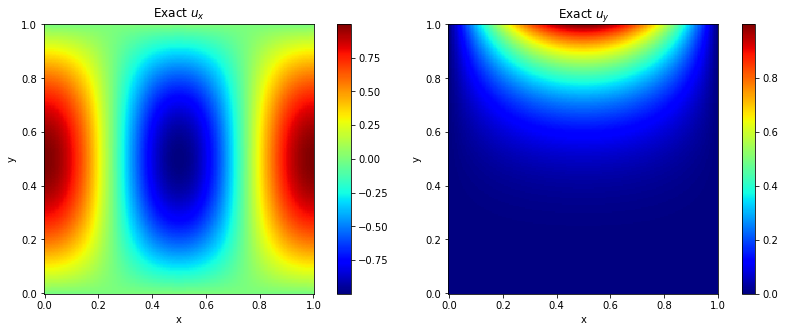

In [ ]:
plot_exact_solution()

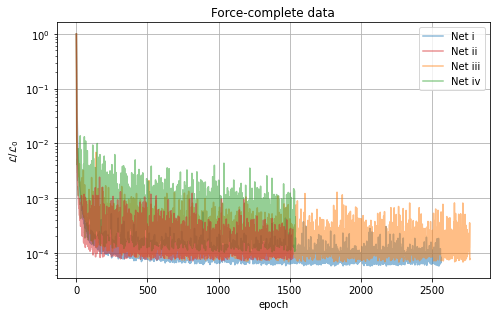

In [50]:
plot_architecture_comparison()

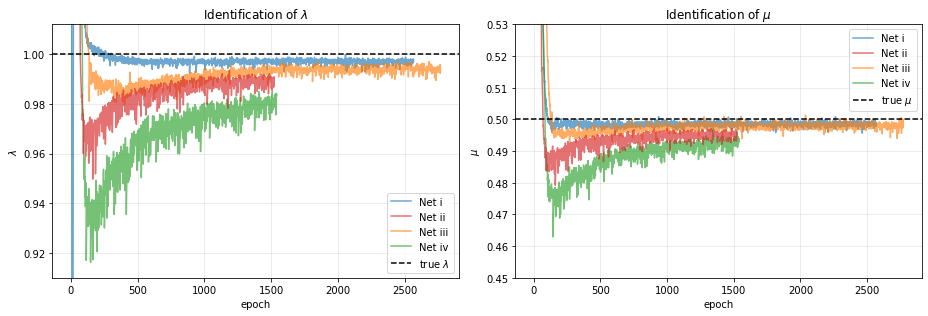

In [49]:
plot_material_parameters()

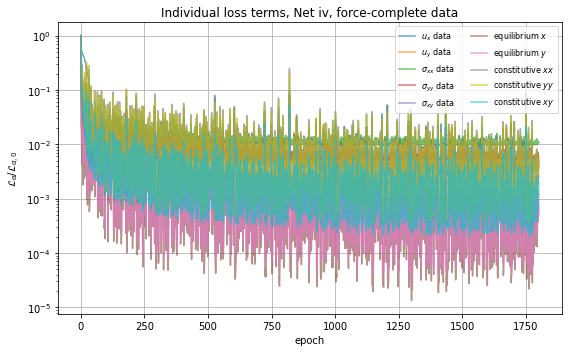

In [ ]:
plot_individual_loss_terms()

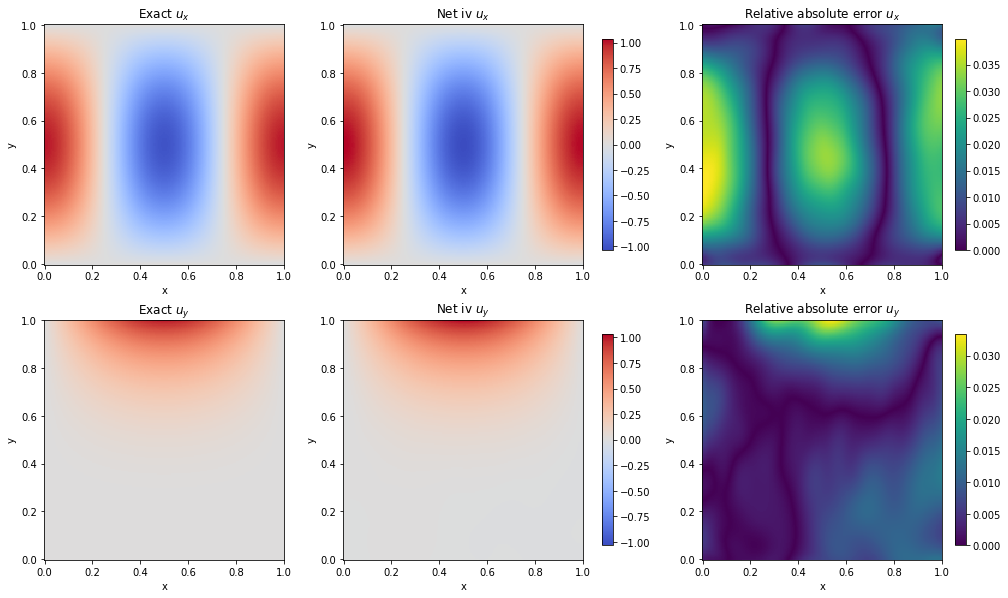

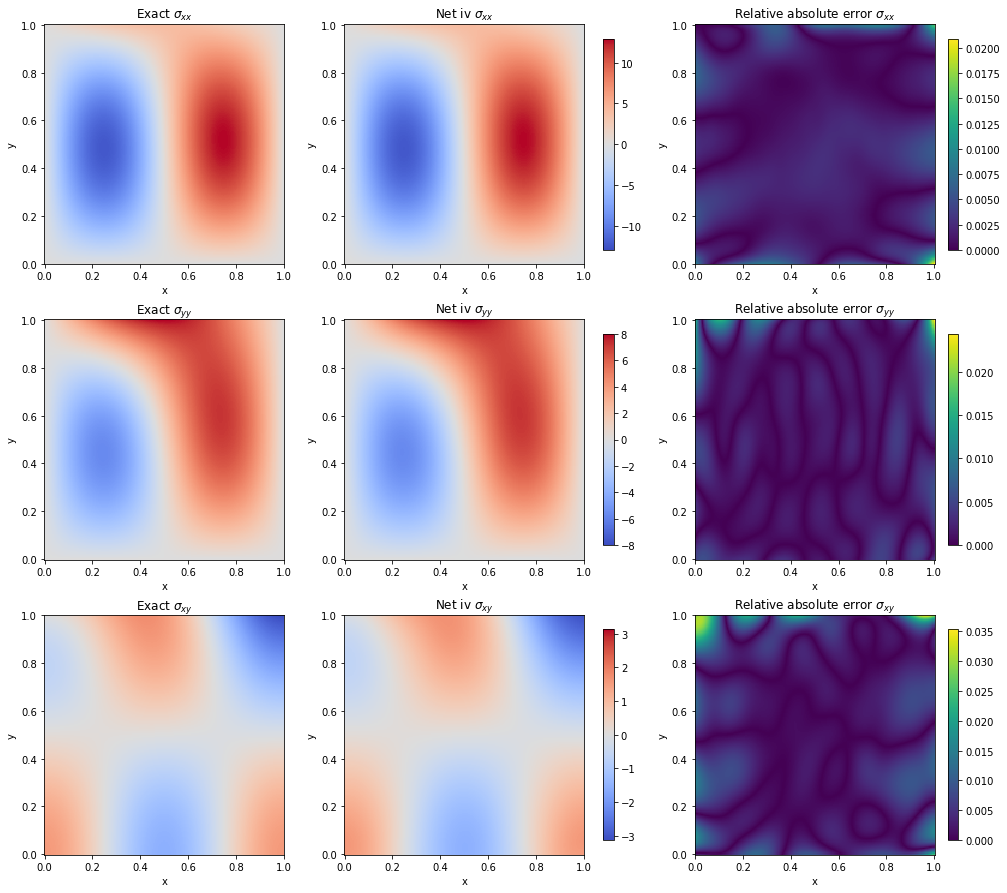

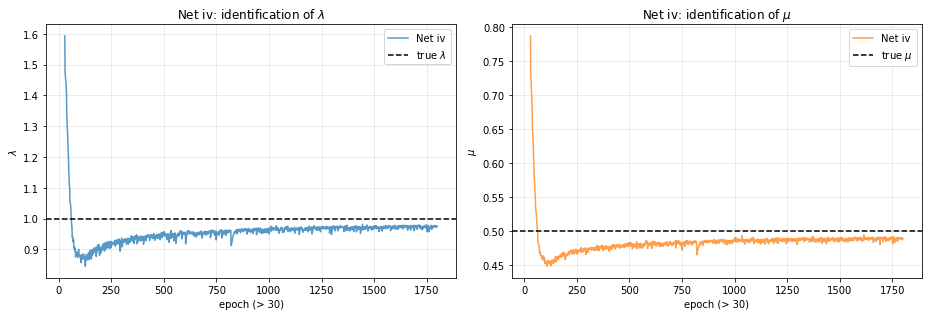

In [ ]:
plot_displacement_comparison()
plot_stress_comparison()
plot_selected_material_parameters()

In [13]:
import time
def train_net_iii_for_data_size(n_side, seed=SEED):
    torch.manual_seed(seed)
    xy = uniform_grid(n_side)
    observed = observed_fields(xy, seed + 20)
    loader = DataLoader(TensorDataset(xy, observed), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(seed + 1))
    model = PINNNetIII()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_history = []
    time_history = []
    lambda_history = []
    mu_history = []
    best_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    start_time = time.perf_counter()
    for epoch in range(EPOCHS):
        loss_sum = 0.0
        samples = 0
        for xy_batch, observed_batch in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = compute_losses(model, xy_batch, observed_batch, training=True)[0]
            loss.backward()
            optimizer.step()
            loss_sum += loss.detach().item() * len(xy_batch)
            samples += len(xy_batch)
        epoch_loss = loss_sum / samples
        loss_history.append(epoch_loss)
        time_history.append(time.perf_counter() - start_time)
        lambda_history.append(model.lame_lambda.detach().item())
        mu_history.append(model.lame_mu.detach().item())
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = clone_model_state(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epoch % PRINT_EVERY == 0:
            print(f"Data {n_side}x{n_side} | epoch {epoch} | loss={epoch_loss:.6e} | lambda={lambda_history[-1]:.6f} | mu={mu_history[-1]:.6f}")
        if epochs_without_improvement >= PATIENCE:
            break
    model.load_state_dict(best_state)
    model.eval()
    return {"model": model, "loss": np.asarray(loss_history), "time": np.asarray(time_history), "lambda_history": np.asarray(lambda_history), "mu_history": np.asarray(mu_history)}

def run_data_size_study(data_sides=(10, 40, 80, 160)):
    study_results = {}
    for n_side in data_sides:
        print(f"\nTraining Net iii with {n_side}x{n_side} points")
        study_results[n_side] = train_net_iii_for_data_size(n_side)
    return study_results

def plot_data_size_study(study_results):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for n_side, result in study_results.items():
        normalized_loss = result["loss"] / result["loss"][0]
        axes[0].plot(np.arange(len(normalized_loss)), normalized_loss, label=f"Data {n_side}x{n_side}", alpha=0.65)
        axes[1].plot(result["time"], normalized_loss, label=f"Data {n_side}x{n_side}", alpha=0.65)
    axes[0].set(xlabel="epochs", ylabel=r"$\mathcal{L}/\mathcal{L}_0$")
    axes[1].set(xlabel="Time (s)", ylabel=r"$\mathcal{L}/\mathcal{L}_0$")
    axes[0].set_yscale("log")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig("force_complete_data_size_study.pdf", bbox_inches="tight")
    plt.show()


Training Net iii with 10x10 points
Data 10x10 | epoch 0 | loss=2.090063e+03 | lambda=1.998238 | mu=1.998034
Data 10x10 | epoch 500 | loss=1.434417e+02 | lambda=1.801330 | mu=2.393911
Data 10x10 | epoch 1000 | loss=4.251511e+01 | lambda=1.653949 | mu=2.442291
Data 10x10 | epoch 1500 | loss=2.144086e+01 | lambda=1.804500 | mu=2.325736
Data 10x10 | epoch 2000 | loss=9.974670e+00 | lambda=1.991436 | mu=2.169844
Data 10x10 | epoch 2500 | loss=1.355978e+01 | lambda=2.126852 | mu=2.052290
Data 10x10 | epoch 3000 | loss=6.106218e+00 | lambda=2.239054 | mu=1.867972
Data 10x10 | epoch 3500 | loss=5.867885e+00 | lambda=2.267604 | mu=1.699558
Data 10x10 | epoch 4000 | loss=4.192523e+00 | lambda=2.215486 | mu=1.576366
Data 10x10 | epoch 4500 | loss=1.651622e+00 | lambda=2.207166 | mu=1.381975
Data 10x10 | epoch 5000 | loss=6.876242e-01 | lambda=2.172963 | mu=1.174701
Data 10x10 | epoch 5500 | loss=4.883619e-01 | lambda=2.047452 | mu=1.054148
Data 10x10 | epoch 6000 | loss=3.200541e-01 | lambda=1.9

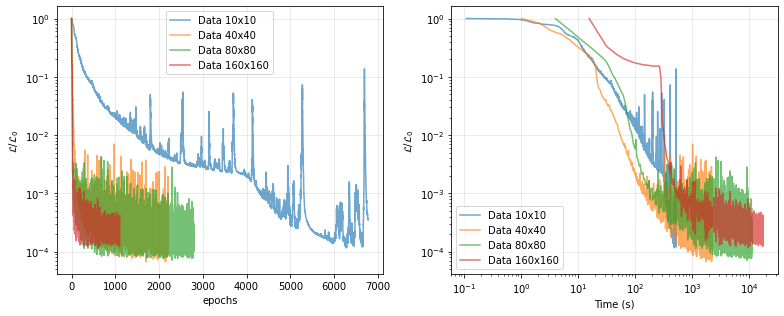

In [14]:
data_size_results = run_data_size_study()
plot_data_size_study(data_size_results)

# Transfer learning

In [15]:
from pathlib import Path
def exact_fields_for_parameters(xy, lambda_true, mu_true):
    displacement = exact_displacement(xy)
    eps_xx, eps_yy, eps_xy = exact_strain(xy).split(1, dim=1)
    sigma_xx = (lambda_true + 2.0 * mu_true) * eps_xx + lambda_true * eps_yy
    sigma_yy = (lambda_true + 2.0 * mu_true) * eps_yy + lambda_true * eps_xx
    sigma_xy = 2.0 * mu_true * eps_xy
    stress = torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)
    return torch.cat((displacement, stress), dim=1)

def body_force_for_parameters(xy, lambda_true, mu_true):
    x, y = xy[:, 0:1], xy[:, 1:2]
    fx = lambda_true * (4.0 * torch.pi**2 * torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y) - torch.pi * torch.cos(torch.pi * x) * Q * y**3)
    fx += mu_true * (9.0 * torch.pi**2 * torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y) - torch.pi * torch.cos(torch.pi * x) * Q * y**3)
    fy = lambda_true * (-3.0 * torch.sin(torch.pi * x) * Q * y**2 + 2.0 * torch.pi**2 * torch.sin(2.0 * torch.pi * x) * torch.cos(torch.pi * y))
    fy += mu_true * (-6.0 * torch.sin(torch.pi * x) * Q * y**2 + 2.0 * torch.pi**2 * torch.sin(2.0 * torch.pi * x) * torch.cos(torch.pi * y) + 0.25 * torch.pi**2 * torch.sin(torch.pi * x) * Q * y**4)
    return torch.cat((fx, fy), dim=1)

def transfer_observations(xy, lambda_true, mu_true, seed):
    exact = exact_fields_for_parameters(xy, lambda_true, mu_true)
    if not USE_NOISY_DATA:
        return exact
    scales = torch.amax(torch.abs(exact), dim=0, keepdim=True).clamp_min(torch.finfo(exact.dtype).eps)
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * scales * noise

def compute_transfer_loss(model, xy, observed, lambda_true, mu_true):
    xy = xy.detach().clone().requires_grad_(True)
    prediction = model(xy)
    ux, uy, sigma_xx, sigma_yy, sigma_xy = split_prediction(prediction)
    predicted_stress = torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)
    constitutive_stress = constitutive_stress_from_displacement(model, xy, ux, uy, create_graph=True)
    residual_constitutive = predicted_stress - constitutive_stress
    grad_sigma_xx = torch.autograd.grad(sigma_xx, xy, torch.ones_like(sigma_xx), create_graph=True, retain_graph=True)[0]
    grad_sigma_yy = torch.autograd.grad(sigma_yy, xy, torch.ones_like(sigma_yy), create_graph=True, retain_graph=True)[0]
    grad_sigma_xy = torch.autograd.grad(sigma_xy, xy, torch.ones_like(sigma_xy), create_graph=True, retain_graph=True)[0]
    force = body_force_for_parameters(xy, lambda_true, mu_true)
    residual_x = grad_sigma_xx[:, 0:1] + grad_sigma_xy[:, 1:2] + force[:, 0:1]
    residual_y = grad_sigma_xy[:, 0:1] + grad_sigma_yy[:, 1:2] + force[:, 1:2]
    residual_equilibrium = torch.cat((residual_x, residual_y), dim=1)
    data_error = prediction - observed
    loss_data = sum(torch.mean(data_error[:, index]**2) for index in range(5))
    loss_equilibrium = sum(torch.mean(residual_equilibrium[:, index]**2) for index in range(2))
    loss_constitutive = sum(torch.mean(residual_constitutive[:, index]**2) for index in range(3))
    return loss_data + loss_equilibrium + loss_constitutive

def train_transfer_case(mu_true, initial_state=None, seed=SEED, max_epochs=EPOCHS):
    torch.manual_seed(seed)
    xy = uniform_grid(N_SIDE_TRAIN)
    observed = transfer_observations(xy, LAMBDA_TRUE, mu_true, seed + 20)
    loader = DataLoader(TensorDataset(xy, observed), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(seed + 1))
    model = PINNNetII()
    if initial_state is not None:
        model.load_state_dict(initial_state)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_history = []
    time_history = []
    lambda_history = []
    mu_history = []
    best_loss = float("inf")
    best_epoch = None
    best_state = None
    epochs_without_improvement = 0
    start_time = time.perf_counter()
    for epoch in range(max_epochs):
        loss_sum = 0.0
        samples = 0
        for xy_batch, observed_batch in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = compute_transfer_loss(model, xy_batch, observed_batch, LAMBDA_TRUE, mu_true)
            loss.backward()
            optimizer.step()
            loss_sum += loss.detach().item() * len(xy_batch)
            samples += len(xy_batch)
        epoch_loss = loss_sum / samples
        loss_history.append(epoch_loss)
        time_history.append(time.perf_counter() - start_time)
        lambda_history.append(model.lame_lambda.detach().item())
        mu_history.append(model.lame_mu.detach().item())
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_epoch = epoch
            best_state = clone_model_state(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epoch % PRINT_EVERY == 0:
            print(f"mu_true={mu_true:.2f} | epoch={epoch:5d} | loss={epoch_loss:.6e} | lambda={lambda_history[-1]:.6f} | mu={mu_history[-1]:.6f}")
        if epochs_without_improvement >= PATIENCE:
            print(f"mu_true={mu_true:.2f} | early stopping at epoch {epoch}")
            break
    model.load_state_dict(best_state)
    model.eval()
    return {
        "model": model,
        "loss": np.asarray(loss_history),
        "time": np.asarray(time_history),
        "lambda_history": np.asarray(lambda_history),
        "mu_history": np.asarray(mu_history),
        "best_loss": best_loss,
        "best_epoch": best_epoch,
        "best_model_state": best_state,
        "training_time": time_history[-1],
    }

def run_transfer_learning_experiment(base_mu=0.5, target_mus=(2.0, 1.5, 1.0, 0.1)):
    print(f"Pre-training Net ii for mu={base_mu:.2f}")
    pretrained = train_transfer_case(base_mu, initial_state=None, seed=SEED)
    transfer_results = {base_mu: pretrained}
    for index, mu_true in enumerate(target_mus):
        print(f"\nTransfer learning for mu={mu_true:.2f}")
        transfer_results[mu_true] = train_transfer_case(mu_true, initial_state=pretrained["best_model_state"], seed=SEED + 100 * (index + 1))
    return transfer_results

def plot_transfer_learning(transfer_results, base_mu=0.5):
    reference_loss = transfer_results[base_mu]["loss"][0]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for mu_true, result in transfer_results.items():
        normalized_loss = result["loss"] / reference_loss
        axes[0].plot(np.arange(len(normalized_loss)), normalized_loss, label=rf"$\mu={mu_true:.2f}$", alpha=0.65)
        axes[1].plot(result["time"], normalized_loss, label=rf"$\mu={mu_true:.2f}$", alpha=0.65)
    axes[0].set(xlabel="epochs", ylabel=r"$\mathcal{L}/\mathcal{L}_0$")
    axes[1].set(xlabel="Time (s)", ylabel=r"$\mathcal{L}/\mathcal{L}_0$")
    axes[0].set_yscale("log")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.3)
    fig.tight_layout()
    Path("imgs").mkdir(parents=True, exist_ok=True)
    plt.savefig("imgs/force_complete_transfer_learning.pdf", bbox_inches="tight")
    plt.show()

Pre-training Net ii for mu=0.50
mu_true=0.50 | epoch=    0 | loss=1.294608e+03 | lambda=2.065543 | mu=2.007106
mu_true=0.50 | epoch=  500 | loss=1.585985e+00 | lambda=0.984126 | mu=0.501849
mu_true=0.50 | epoch= 1000 | loss=6.209618e-01 | lambda=0.992421 | mu=0.501644
mu_true=0.50 | epoch= 1500 | loss=4.064937e-01 | lambda=0.994273 | mu=0.501981
mu_true=0.50 | epoch= 2000 | loss=2.034007e-01 | lambda=0.995429 | mu=0.500392
mu_true=0.50 | early stopping at epoch 2016

Transfer learning for mu=2.00
mu_true=2.00 | epoch=    0 | loss=9.360206e+02 | lambda=0.905325 | mu=0.630379
mu_true=2.00 | epoch=  500 | loss=1.262824e+00 | lambda=0.986919 | mu=1.983037
mu_true=2.00 | early stopping at epoch 757

Transfer learning for mu=1.50
mu_true=1.50 | epoch=    0 | loss=2.760609e+02 | lambda=0.891923 | mu=0.638743
mu_true=1.50 | epoch=  500 | loss=5.260938e-01 | lambda=0.993640 | mu=1.490009
mu_true=1.50 | early stopping at epoch 936

Transfer learning for mu=1.00
mu_true=1.00 | epoch=    0 | loss=

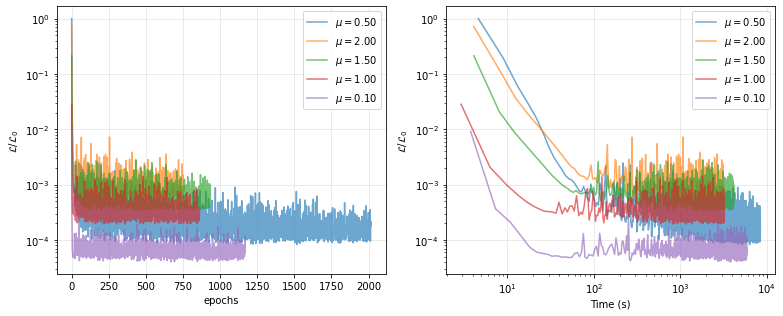

In [16]:
transfer_results = run_transfer_learning_experiment()
plot_transfer_learning(transfer_results)